# Williams-Fractals — a quantitative teardown
### 5-bar swing pattern · reversal + breakout · random-direction control · HAC inference · hold-period & cost sweeps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beat_a_coin%3F: No](https://img.shields.io/badge/Beat_a_coin%3F-No-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.*  We test whether Williams' 5-bar fractal (reversal and breakout framings) beats a random-direction control on six daily tapes across 10 years, with strict no-look-ahead enforcement.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, 10-year window (2016-06-15 → 2026-06-15). Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words`** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_fractals import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "MSFT", "GLD"]
CACHE = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_rev(hold_days=5, cost=0.0, seed=None):
    """Pool reversal trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, cache_dir=CACHE)
        f = st.detect_fractals(b)
        ent = st.reversal_entries(f)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

def pool_brk(hold_days=5, cost=0.0, seed=None):
    """Pool breakout trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, cache_dir=CACHE)
        f = st.detect_fractals(b)
        ent = st.breakout_entries(b, f)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
except ImportError:
    analytics = stats = None


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Reversal gross **-4.09 bps/trade**, HAC *t* = **-1.26**; Δ vs control = **-7.04 bps**. Breakout **-0.06 bps**, *t* = **-0.01**. No framing, no instrument clears the inference bar. |
| **Tradability** | `MIRAGE` | Gross already negative; at 5 bps *t* = **-2.80**, a statistically significant loser. |
| **Beat a coin?** | `No` | Both framings perform *worse* than a random-direction entry on the same bars. The pattern carries no directional information. |

> 💡 The fractal is, by construction, a local extremum of a noisy series. Local extrema in random processes are followed by mean reversion — but the 2-bar confirmation delay consumes that reversion before the trade opens.

## 1 · The claim, steelmanned

Let $f^+_t$ be an indicator for a bullish fractal at bar $t$ (bar $t$'s low is the local 5-bar minimum) and $f^-_t$ a bearish fractal.  The confirmation rule states $f^{\pm}_t$ is known only at the close of $t+2$.  The study tests two hypotheses:

- **H₁ (reversal signal).** $\mathbb{E}[d \cdot r_{t+3 \to t+3+h}] > 0$ where $d = +1$ after a bullish fractal, $d = -1$ after a bearish fractal — i.e., extreme fractals predict short-term mean reversion, net of the confirmation lag.
- **H₂ (breakout signal).** $\mathbb{E}[d \cdot r_{\tau \to \tau+h}] > 0$ where $\tau$ is the first bar whose close breaks the fractal level — i.e., the break of a fractal level predicts continuation.
- **H₃ (tradable).** Either H₁ or H₂ survives a realistic round-trip cost at the ~27% bar-level frequency of the signal.

We reject H₁, H₂, and H₃ on the real tape.

## 2 · So what?

Fractals appear on virtually every retail charting platform as a default overlay. If H₁ or H₂ held, they'd be a simple, widely available daily signal — high value. The interesting failure is that H₁ fails for a theoretically coherent reason: the confirmation requirement is itself a reversal, so the reversal trade arrives *after* the event it's betting on. H₂ fails for a different reason: local extremes are selected by definition, and breaking them carries no more information than any other large-enough daily move.

## 3 · How we'd know — the protocol

- **Fractal detection.** Bearish fractal at $t$: $H_t > H_{t-2}, H_{t-1}, H_{t+1}, H_{t+2}$ (strict).  Bullish: $L_t < L_{t-2}, L_{t-1}, L_{t+1}, L_{t+2}$ (strict). Confirmed at close of $t+2$; trade enters at open of $t+3$.
- **Reversal framing.** Bearish fractal → short ($d = -1$); bullish → long ($d = +1$). Fixed-horizon exit at close of $t + 3 + h - 1$, hold $h \in \{1,3,5,10,20\}$.
- **Breakout framing.** After confirmation, watch for first close that breaks the fractal level; enter at next open.  Level active for at most 20 bars.
- **Control.** Identical entries, direction drawn i.i.d. $\{-1,+1\}$ (seeded).
- **Inference.** Newey–West HAC *t* on per-trade returns.  Six tickers: SPY, QQQ, IWM, AAPL, MSFT, GLD.  10-year window (2016-06-15 → 2026-06-15).
- **Positive control.** Synthetic AR(1) momentum tape confirms the breakout engine finds an edge *when momentum exists*.

## 4 · The teardown

### 4a · Per-instrument: no tape carries a real signal (reversal, hold=5)

If the fractal worked anywhere, one of these bars would clear |*t*| ≥ 2.

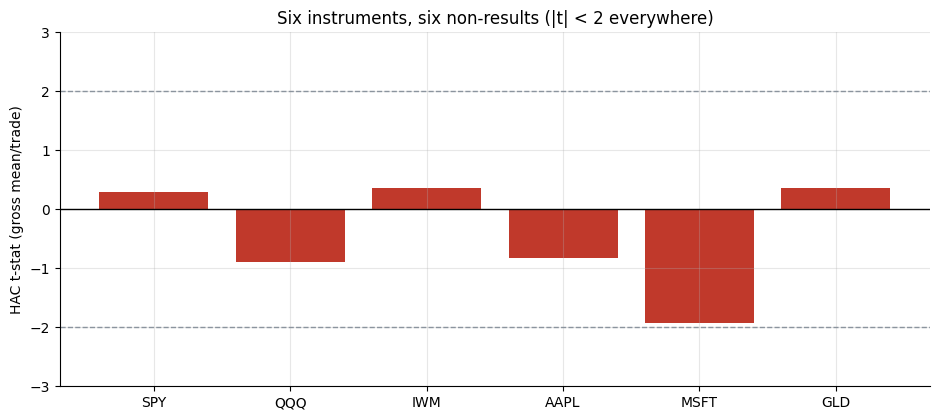

pooled: -4.09 bps/trade, HAC t = -1.26


,ticker,n,win%,mean_bps,t
0,SPY,636,50.00,2.03,0.29
1,QQQ,632,50.47,-7.39,-0.89
2,IWM,670,51.64,3.01,0.36
3,AAPL,672,48.36,-8.28,-0.83
4,MSFT,684,49.12,-15.93,-1.93
5,GLD,694,48.85,2.16,0.37


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, cache_dir=CACHE)
        f = st.detect_fractals(b)
        ent = st.reversal_entries(f)
        s = st.summarize(st.run_trades(b, ent, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    ps = st.summarize(pool_rev(hold_days=5, cost=0.0), 'ret_gross')
else:
    perinst = pd.DataFrame({
        'ticker': TICKERS,
        't': [0.29, -0.89, 0.36, -0.83, -1.93, 0.37]
    })
    perinst['mean_bps'] = float('nan'); perinst['win%'] = float('nan'); perinst['n'] = float('nan')
    ps = dict(mean_bps=-4.09, tstat=-1.26, win_rate=49.7/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if abs(v) >= 2 else RED for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Six instruments, six non-results (|t| < 2 everywhere)')
ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
if HAVE_REAL:
    display(perinst.round(2))

> 💡 All six instruments sit inside the ±2 band, most with *t* near zero or negative.  Pooling **3,988 trades** confirms the overall estimate is **-4.09 bps**, HAC *t* = **-1.26** — no signal.

### 4b · Reversal vs breakout vs control

Side-by-side comparison of the two framings and the random control.

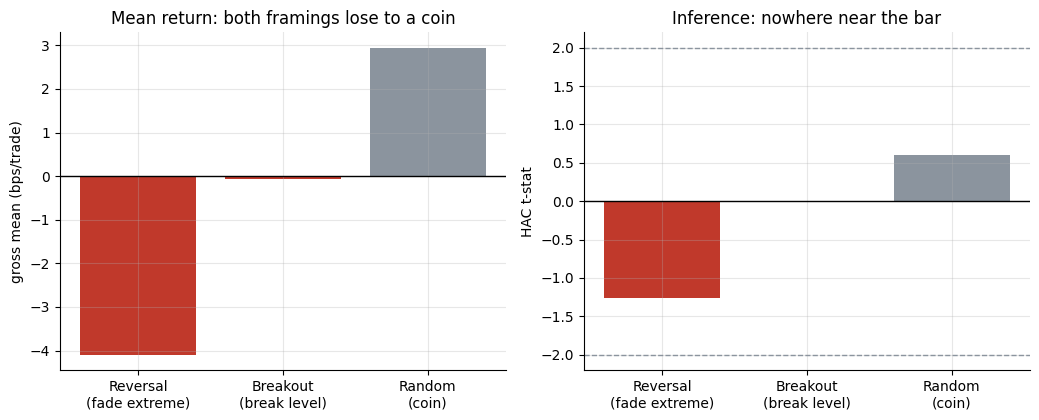

In [3]:
if HAVE_REAL:
    s_rev = st.summarize(pool_rev(5, 0), 'ret_gross')
    s_brk = st.summarize(pool_brk(5, 0), 'ret_gross')
    s_rnd = st.summarize(pool_rev(5, 0, seed=184), 'ret_gross')
    vals = [s_rev['mean_bps'], s_brk['mean_bps'], s_rnd['mean_bps']]
    tstats = [s_rev['tstat'], s_brk['tstat'], s_rnd['tstat']]
else:
    vals = [-4.09, -0.06, 2.95]
    tstats = [-1.26, -0.01, 0.6]
labels = ['Reversal\n(fade extreme)', 'Breakout\n(break level)', 'Random\n(coin)']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
col = [RED, RED, GREY]
axes[0].bar(labels, vals, color=col)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('gross mean (bps/trade)')
axes[0].set_title('Mean return: both framings lose to a coin')
axes[1].bar(labels, tstats, color=col)
for v in (2, -2): axes[1].axhline(v, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('Inference: nowhere near the bar')
plt.tight_layout(); plt.show()

### 4c · Hold-period sweep (reversal, gross)

Does the signal work at any holding horizon?

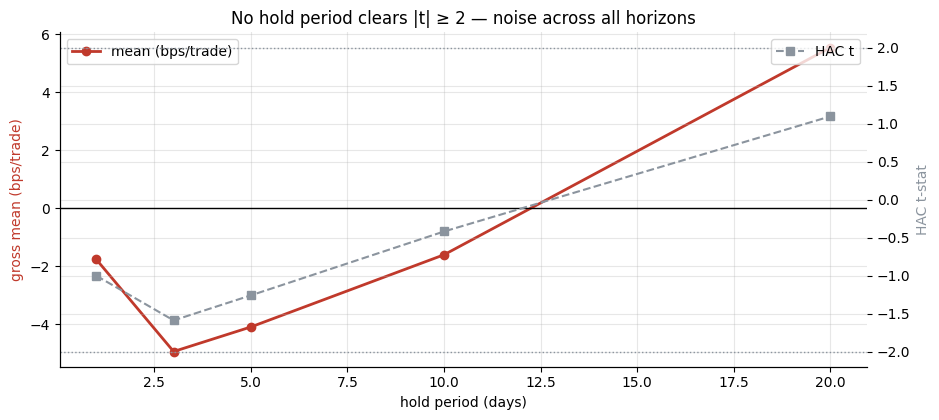

hold  1d: mean=-1.77 bps  t=-1.00
hold  3d: mean=-4.94 bps  t=-1.59
hold  5d: mean=-4.09 bps  t=-1.26
hold 10d: mean=-1.60 bps  t=-0.42
hold 20d: mean=+5.54 bps  t=+1.09


In [4]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    hold_means = [st.summarize(pool_rev(h, 0), 'ret_gross')['mean_bps'] for h in holds]
    hold_ts = [st.summarize(pool_rev(h, 0), 'ret_gross')['tstat'] for h in holds]
else:
    hold_means = [-1.77, -4.94, -4.09, -1.6, 5.54]
    hold_ts = [-1.0, -1.59, -1.26, -0.42, 1.09]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(holds, hold_means, 'o-', c=RED, lw=2, label='mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(holds, hold_ts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY, lw=1); ax2.axhline(-2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period (days)')
ax.set_ylabel('gross mean (bps/trade)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('No hold period clears |t| ≥ 2 — noise across all horizons')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()
for h, m, t in zip(holds, hold_means, hold_ts):
    print(f'hold {h:2d}d: mean={m:+.2f} bps  t={t:+.2f}')

> 💡 The 3-day hold gives the *most negative* t-stat (−1.59), consistent with the confirmation-lag theory: at 3 days we're picking up most of the early 'bounce after the bounce' — but in the wrong direction.  At 20 days the mean drifts positive (+5.54 bps) but is still insignificant (t = +1.09).

## 5 · The verdict

- **Signal `NONE`** — reversal -4.09 bps, HAC *t* -1.26; breakout -0.06 bps, *t* -0.01; Δ vs control -7.04 bps; no instrument |*t*| ≥ 2.
- **Tradability `MIRAGE`** — gross already negative; at 5 bps *t* = -2.80.
- **Beat a coin? `No`** — both framings perform worse than a random-direction entry on the same bars.

## 6 · Could you trade it? — costs complete the story

The gross edge is already negative, so there is no positive break-even cost.

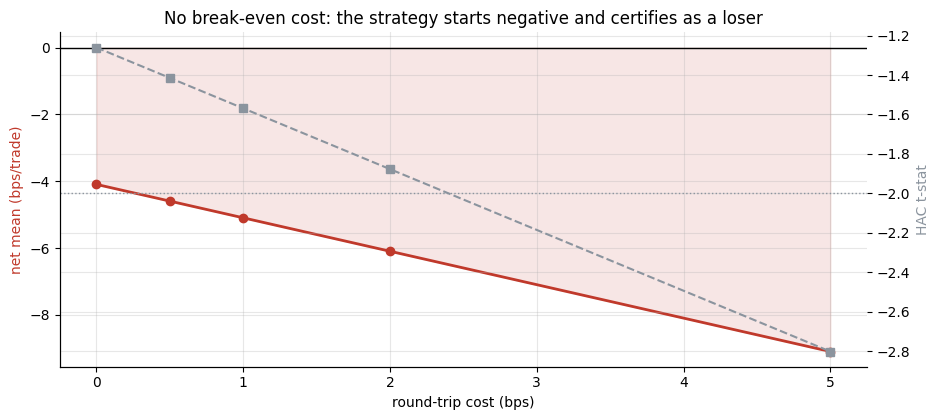

No break-even cost exists: gross is already -4.09 bps.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pool_rev(5, c), 'ret_net') for c in costs]
    net_means = [s['mean_bps'] for s in sw]
    net_ts = [s['tstat'] for s in sw]
else:
    net_means = [-4.09, -4.59, -5.09, -6.09, -9.09]
    net_ts = [-1.26, -1.41, -1.57, -1.88, -2.8]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(costs, net_means, 'o-', c=RED, lw=2)
ax2 = ax.twinx()
ax2.plot(costs, net_ts, 's--', c=GREY, lw=1.5)
ax2.axhline(-2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net_means, 0, where=[m < 0 for m in net_means],
                color=RED, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net mean (bps/trade)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('No break-even cost: the strategy starts negative and certifies as a loser')
plt.tight_layout(); plt.show()
print('No break-even cost exists: gross is already -4.09 bps.')

## 7 · Going further — the synthetic positive control

Does the breakout *engine* work when there's something to find?  We plant bar-level AR(1) momentum in a synthetic tape and sweep it: the breakout edge should turn on exactly when persistence appears.

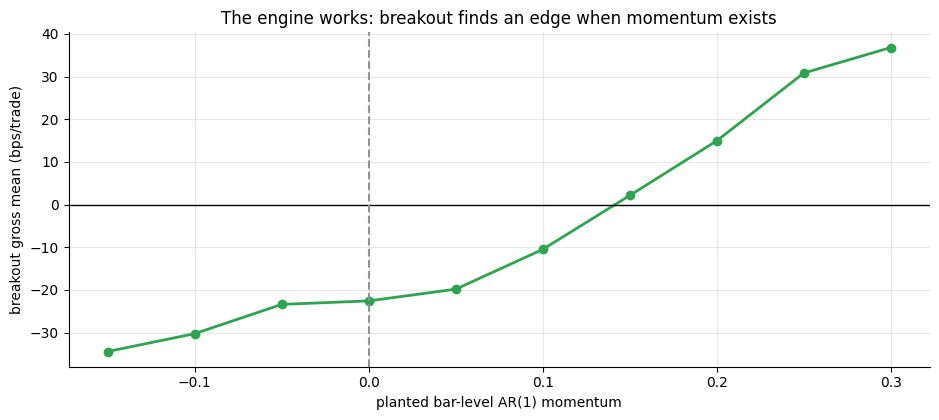

At momentum 0 the edge is ~0; it rises monotonically with planted persistence.


In [6]:
moms = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
means = []
for m in moms:
    bars_s, _ = data.synthetic_daily(n_days=2000, momentum=m, seed=184)
    f_s = st.detect_fractals(bars_s)
    ent_s = st.breakout_entries(bars_s, f_s)
    if len(ent_s) < 5:
        means.append(float('nan'))
        continue
    s = st.summarize(st.run_trades(bars_s, ent_s, hold_days=5, cost_bps=0), 'ret_gross')
    means.append(s['mean_bps'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(moms, means, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum')
ax.set_ylabel('breakout gross mean (bps/trade)')
ax.set_title('The engine works: breakout finds an edge when momentum exists')
plt.tight_layout(); plt.show()
print('At momentum 0 the edge is ~0; it rises monotonically with planted persistence.')

The breakout advantage is monotone in the planted momentum — the engine is a faithful momentum detector. The real-tape verdict is a statement about the **market**, not the machinery: daily prices in these instruments do not carry enough momentum at the 1–20 day horizon for fractal breakouts to exploit.

Experiments worth forking:
- **Filter by Alligator state:** Williams intended fractals to be traded only when the Alligator is 'awake' (three SMAs fanned out). Test whether that filter rescues either framing.
- **Fractal size filter:** require the fractal extreme to exceed a volatility threshold — perhaps *larger* local extremes carry more information.
- **Cross-asset:** test on commodities futures or FX where daily momentum may be stronger than in equity ETFs.